In [8]:
import sympy
from sympy import symbols, Function, Eq, solve, diff, integrate, pi, simplify



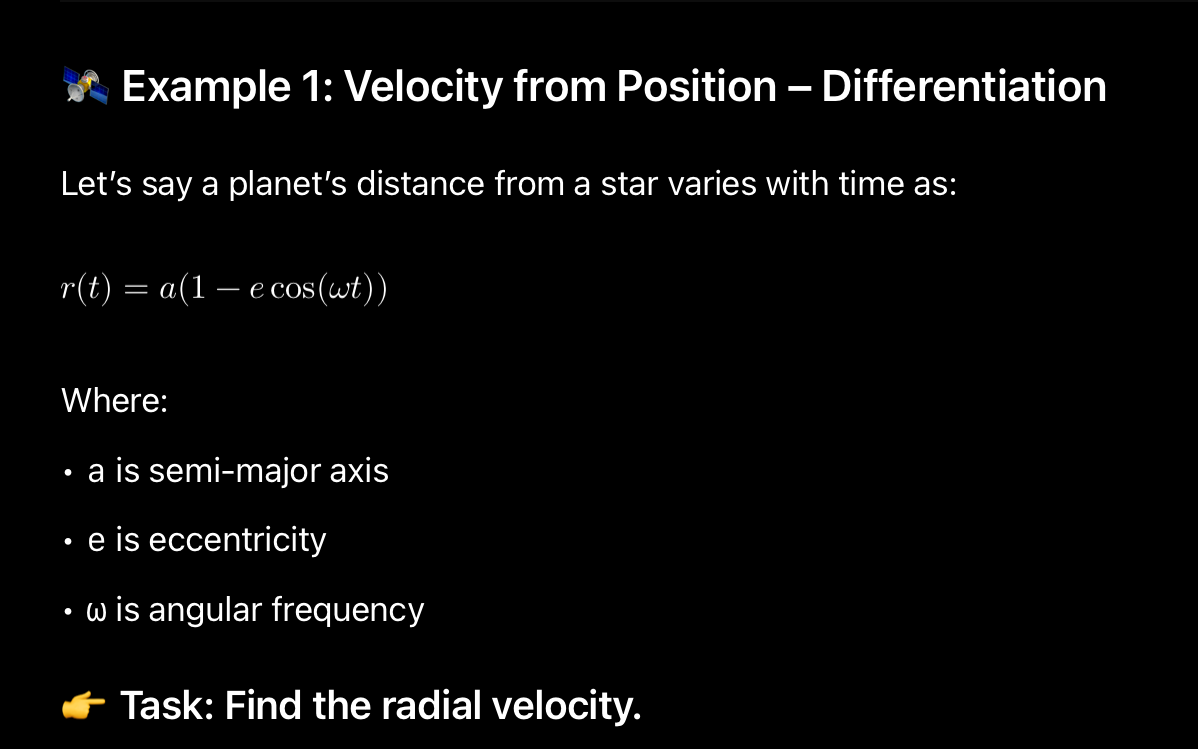

In [9]:
from sympy import symbols, cos, sin, pi, diff, simplify

# Step 1: Define symbols
t = symbols('t', real=True)                          # time in days
semi_major_axis = symbols('a', real=True, positive=True)           # semi-major axis in meters
eccentricity = symbols('e', real=True, positive=True)           # eccentricity
omega = symbols('omega', real=True, positive=True)   # angular frequency in rad/day

# Step 2: Define Pluto's orbital radius function
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))

# Step 3: Differentiate to get radial velocity
radial_velocityFunc = simplify(diff(radial_distanceFunc, t))  # This gives a*e*omega*sin(omega*t)

# Step 4: Define Pluto's orbital parameters
AU_m = 1.496e11                      # 1 AU in meters
a_pluto = 39.48 * AU_m              # semi-major axis in meters
e_pluto = 0.2488
T_pluto_days = 248 * 365.25
omega_pluto = 2 * pi / T_pluto_days
t_eval = 1000  # days

# Step 5: Substitute values
values = {
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto,
    t: t_eval
}

# Step 6: Evaluate in m/day, then convert to m/s
v_r_m_per_day = radial_velocityFunc.subs(values).evalf()
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)

# Step 7: Output
print("Pluto radial velocity at day 1000:")
print(f"{v_r_m_per_day:.2e} m/day")
print(f"{v_r_m_per_sec:.2f} m/s")

Pluto radial velocity at day 1000:
7.06e+6 m/day
81.77 m/s


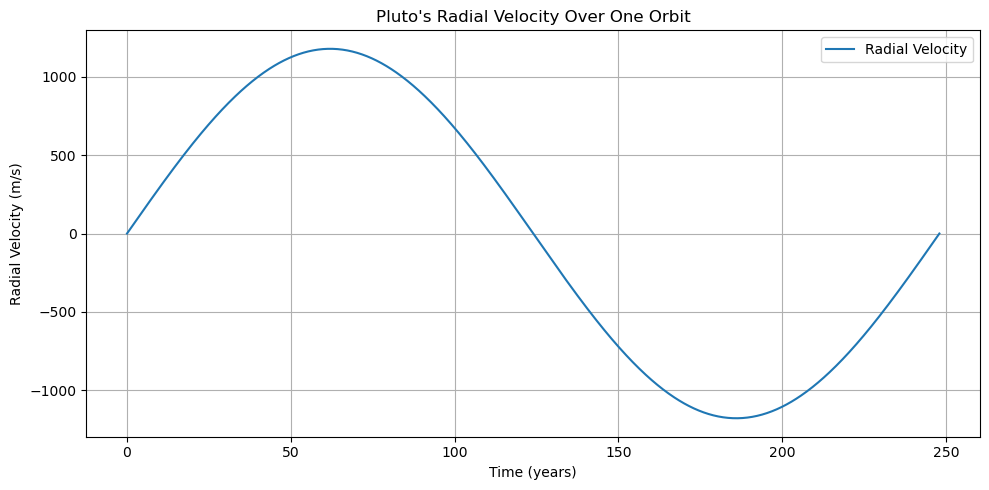

In [10]:
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define symbolic variables
t = symbols('t', real=True)                            # Time (days)
semi_major_axis = symbols('a', real=True, positive=True)             # Semi-major axis (meters)
eccentricity = symbols('e', real=True, positive=True)             # Eccentricity
omega = symbols('omega', real=True, positive=True)     # Angular frequency (rad/day)

# Step 2: Define orbital radius and differentiate to get radial velocity
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))                        # Radial distance as function of time
radial_velocityFunc = simplify(diff(radial_distanceFunc, t))                              # Radial velocity = dr/dt = a*e*omega*sin(omega*t)

# Step 3: Pluto’s orbital parameters
AU_meters = 1.496e11                                    # 1 AU in meters
a_pluto = 39.48 * AU_meters                             # Pluto's semi-major axis in meters
e_pluto = 0.2488                                        # Eccentricity
T_pluto_days = 248 * 365.25                             # Orbital period in days
omega_pluto = 2 * pi / T_pluto_days                     # Angular frequency in rad/day

# Step 4: Convert symbolic radial velocity to a numerical function
radial_velocityFunLamdify = lambdify(t, radial_velocityFunc.subs({
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto
}), modules='numpy')

# Step 5: Generate time values (days) and evaluate radial velocity in m/s
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
v_r_m_per_day = radial_velocityFunLamdify(days)                          # Evaluate radial velocity in m/day
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)             # Convert to m/s

# Step 6: Plot radial velocity over time
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, v_r_m_per_sec, label="Radial Velocity")  # Time in years
plt.title("Pluto's Radial Velocity Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

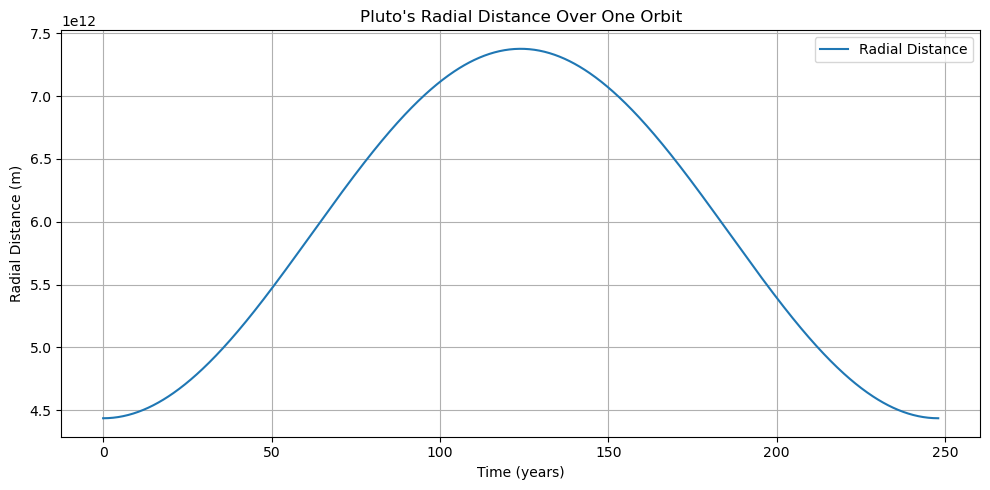

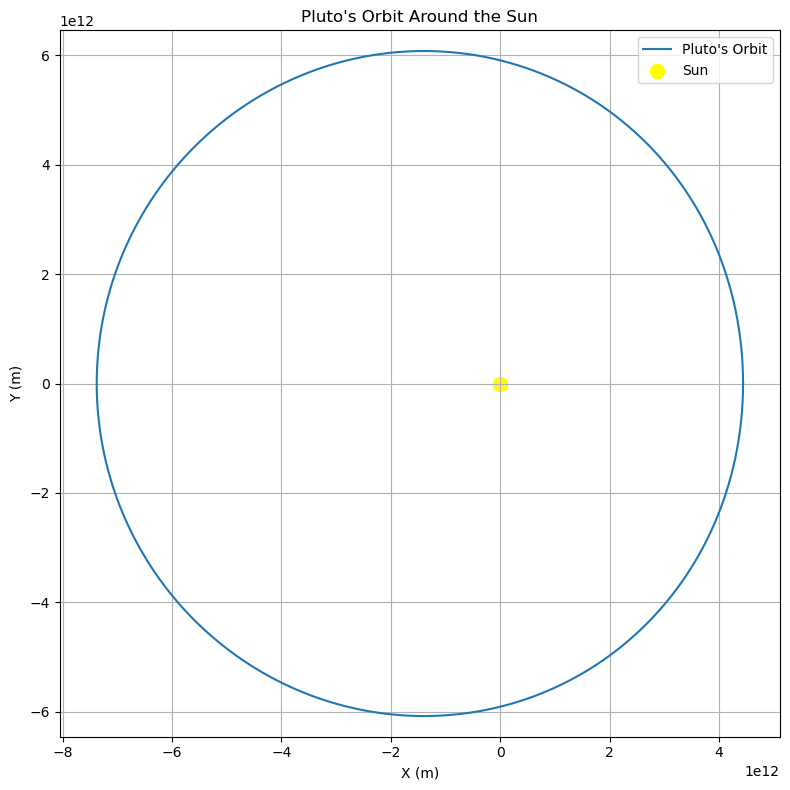

'Radial Velocity func'

a*e*omega*sin(omega*t)

'Radial Velocity func simplified'

a*e*omega*sin(omega*t)

def _lambdifygenerated(t):
    return 32444957.0643174*pi*sin(2.20794418317105e-5*pi*t)



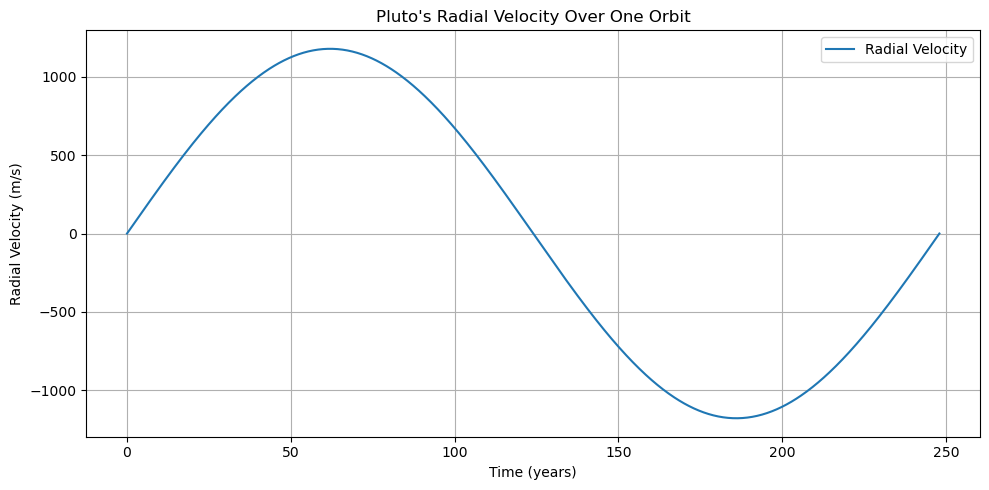

In [ ]:
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify
import numpy as np
import matplotlib.pyplot as plt
import inspect

# Define symbolic variables
t = symbols('t', real=True)                                     # Time (days)
semi_major_axis = symbols('a', real=True, positive=True)        # Semi-major axis (meters)
eccentricity = symbols('e', real=True, positive=True)           # Eccentricity
omega = symbols('omega', real=True, positive=True)              # Angular frequency (rad/day)

# Pluto’s orbital parameters
AU_meters = 1.496e11                                    # 1 AU in meters
a_pluto = 39.48 * AU_meters                             # Pluto's semi-major axis in meters
e_pluto = 0.2488                                        # Eccentricity
T_pluto_days = 248 * 365.25                             # Orbital period in days
omega_pluto = 2 * pi / T_pluto_days  

# Plot radial distance over one orbit 
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))                        # Radial distance as function of time
#Plot Pluto's radial distance over one orbit
radial_distanceFuncSimp = radial_distanceFunc.subs({
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto
})
radial_distanceFunLamdify = lambdify(t, radial_distanceFuncSimp, modules='numpy')
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
radial_distance_m = radial_distanceFunLamdify(days)     # Evaluate radial distance in meters
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, radial_distance_m, label="Radial Distance")  # Time in years
plt.title("Pluto's Radial Distance Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate radial velocity
radial_velocityFunc = diff(radial_distanceFunc, t)                              # Radial velocity = dr/dt = a*e*omega*sin(omega*t)
display('Radial Velocity func',radial_velocityFunc)  
radial_velocityFuncSimp = simplify(radial_velocityFunc)                         # Radial velocity = dr/dt = a*e*omega*sin(omega*t)
display('Radial Velocity func simplified',radial_velocityFuncSimp)

                   # Angular frequency in rad/day



# Step 4: Convert symbolic radial velocity to a numerical function
radial_velocityFunLamdify = lambdify(t, radial_velocityFunc.subs({
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto
}), modules='numpy')
print(inspect.getsource(radial_velocityFunLamdify ))

# Step 5: Generate time values (days) and evaluate radial velocity in m/s
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
v_r_m_per_day = radial_velocityFunLamdify(days)                          # Evaluate radial velocity in m/day
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)             # Convert to m/s

# Step 6: Plot radial velocity over time
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, v_r_m_per_sec, label="Radial Velocity")  # Time in years
plt.title("Pluto's Radial Velocity Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

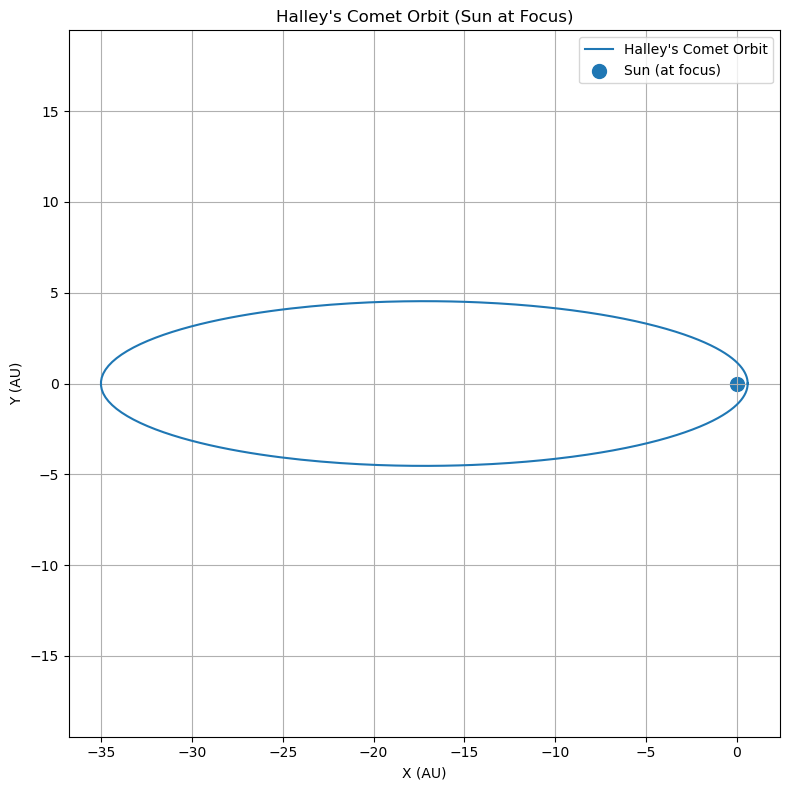

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Halley's Comet orbital parameters
a_AU = 17.8       # Semi-major axis in AU
e = 0.967         # Eccentricity

# Parameter for plotting
theta = np.linspace(0, 2 * np.pi, 1000)

# Polar equation centered on the Sun (focus)
r = (a_AU * (1 - e**2)) / (1 + e * np.cos(theta))

# Convert to Cartesian coordinates
x = r * np.cos(theta)
y = r * np.sin(theta)

# Plotting
plt.figure(figsize=(8, 8))
plt.plot(x, y, label="Halley's Comet Orbit")
plt.scatter(0, 0, marker='o', s=100, label='Sun (at focus)')
plt.title("Halley's Comet Orbit (Sun at Focus)")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.axis('equal')  # Preserve the true shape
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

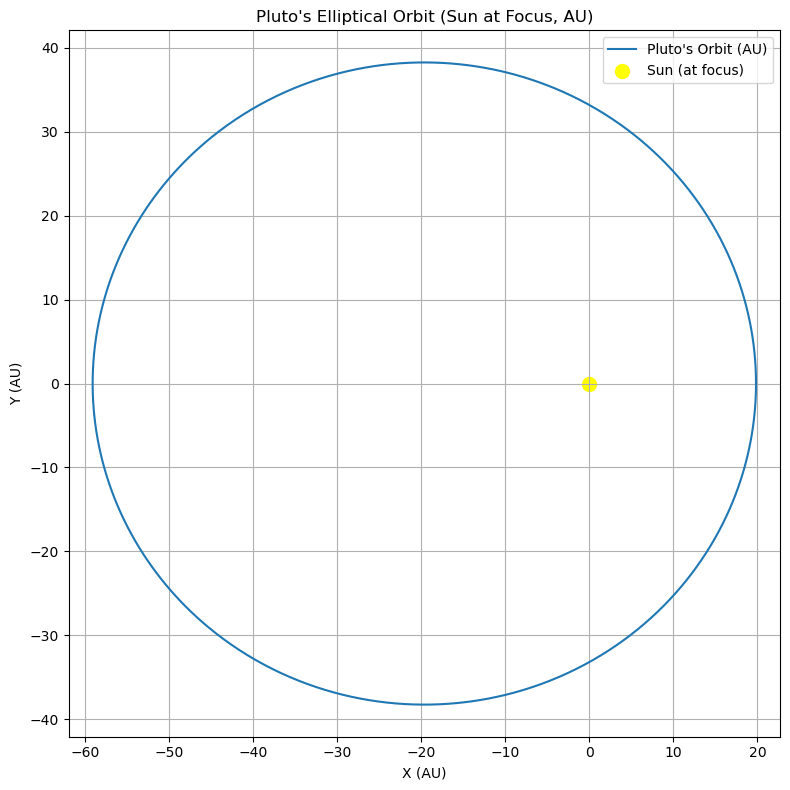

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Pluto's orbital parameters
a_AU = 39.48        # Semi-major axis in AU
e = 0.2488          # Eccentricity

# Angular range
theta = np.linspace(0, 2 * np.pi, 1000)

# Radial distance in AU using ellipse formula
r = (a_AU * (1 - e**2)) / (1 + e * np.cos(theta))

# Polar to Cartesian conversion
x = r * np.cos(theta)
y = r * np.sin(theta)

# Shift orbit to place Sun at one focus
x_shifted = x - a_AU * e

# Plot
plt.figure(figsize=(8, 8))
plt.plot(x_shifted, y, label="Pluto's Orbit (AU)")
plt.scatter(0, 0, color='yellow', s=100, label="Sun (at focus)")
plt.title("Pluto's Elliptical Orbit (Sun at Focus, AU)")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.axis('equal')  # Critical to preserve ellipse shape
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()